Master: 3150 obs, 126 countries
Total features: 20 (18 base + 1 group + 2 interactions)
After transforms: 1344 obs
Observations: 1344 | Features: 20

✓ All models fitted on full dataset
  Elastic Net  →  best l1_ratio: 0.50  |  alpha: 0.0096
  LASSO        →  best alpha:    0.0059
  Ridge        →  best alpha:    15.1991
  RF OOB R²    →  0.7365

[1/3] Plotting VIF chart...


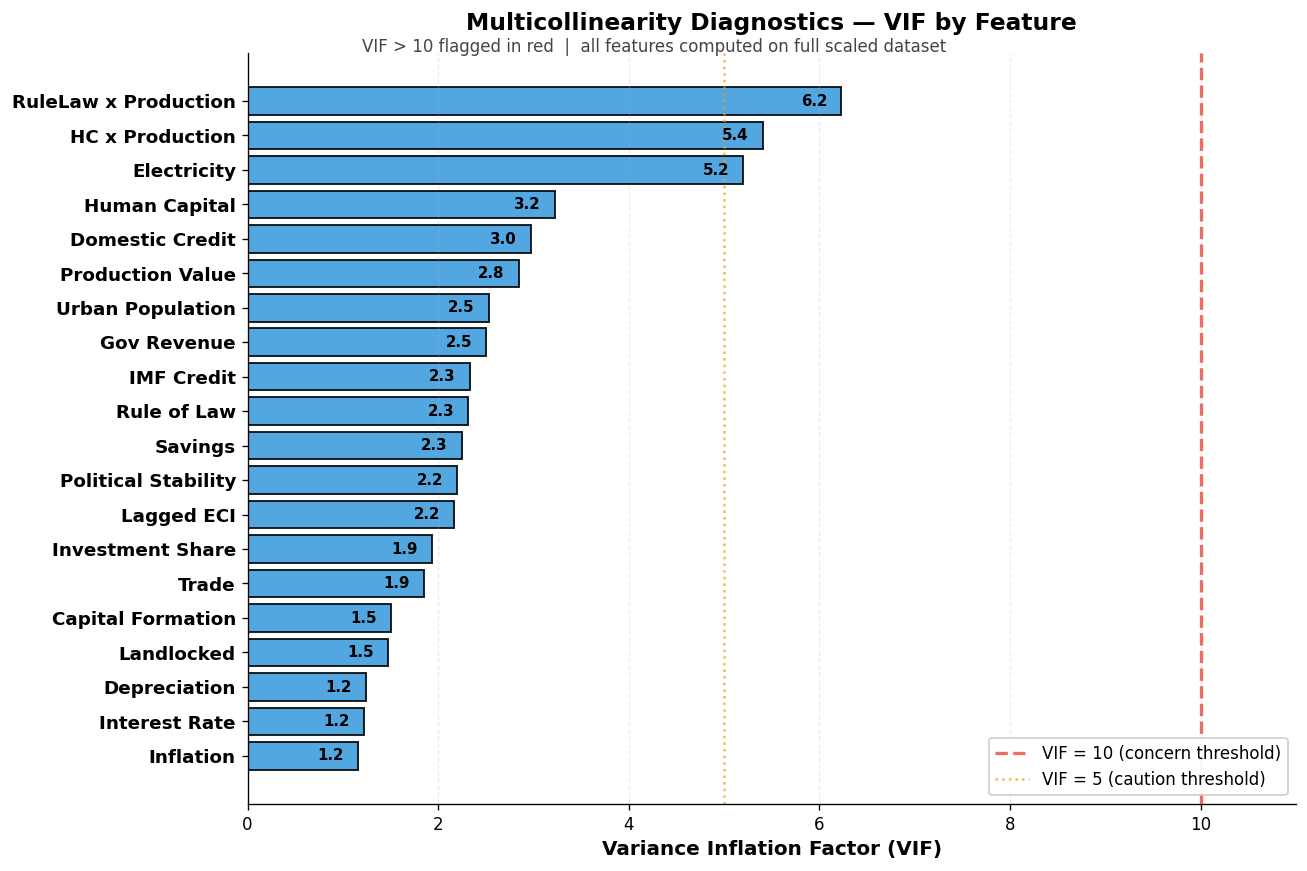

  ✓ Saved ..\figures\ml\VIF_model2_resource_rich.{png,pdf}

[4/5] Plotting 3-panel coefficient comparison...


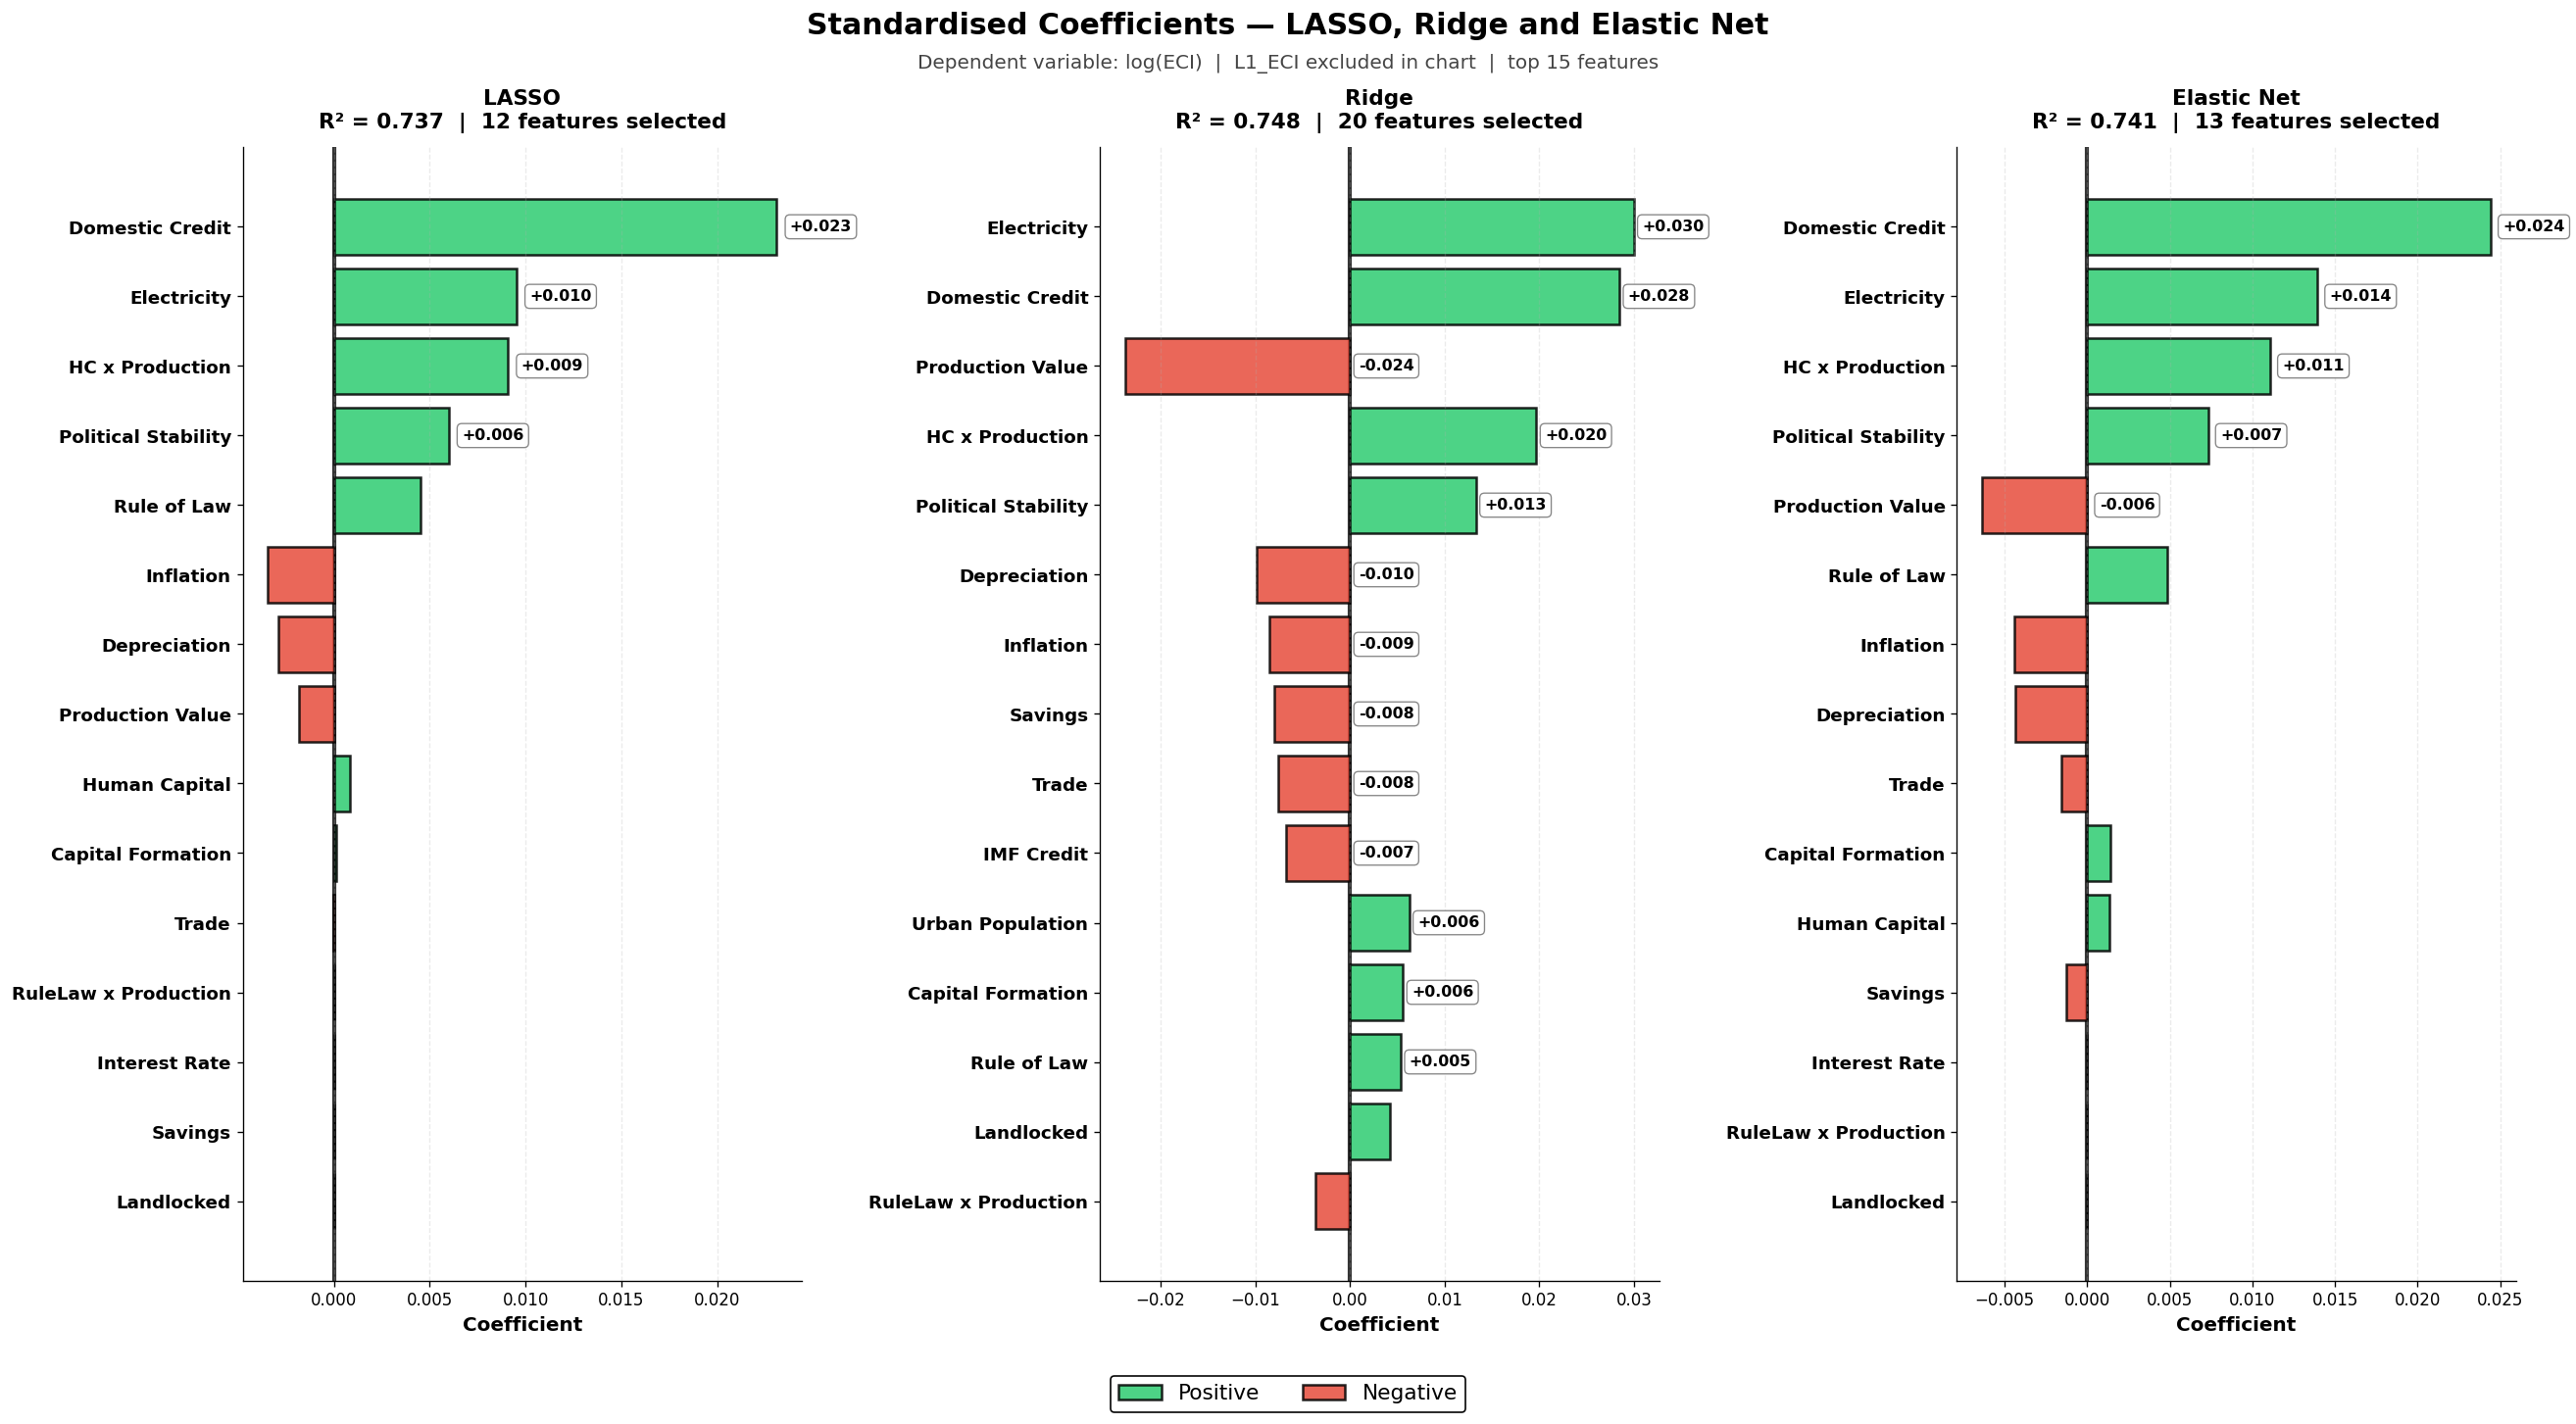

  ✓ Saved Coef_Comparison_model2_resource_rich.{png,pdf}

[5/5] Plotting model agreement chart...


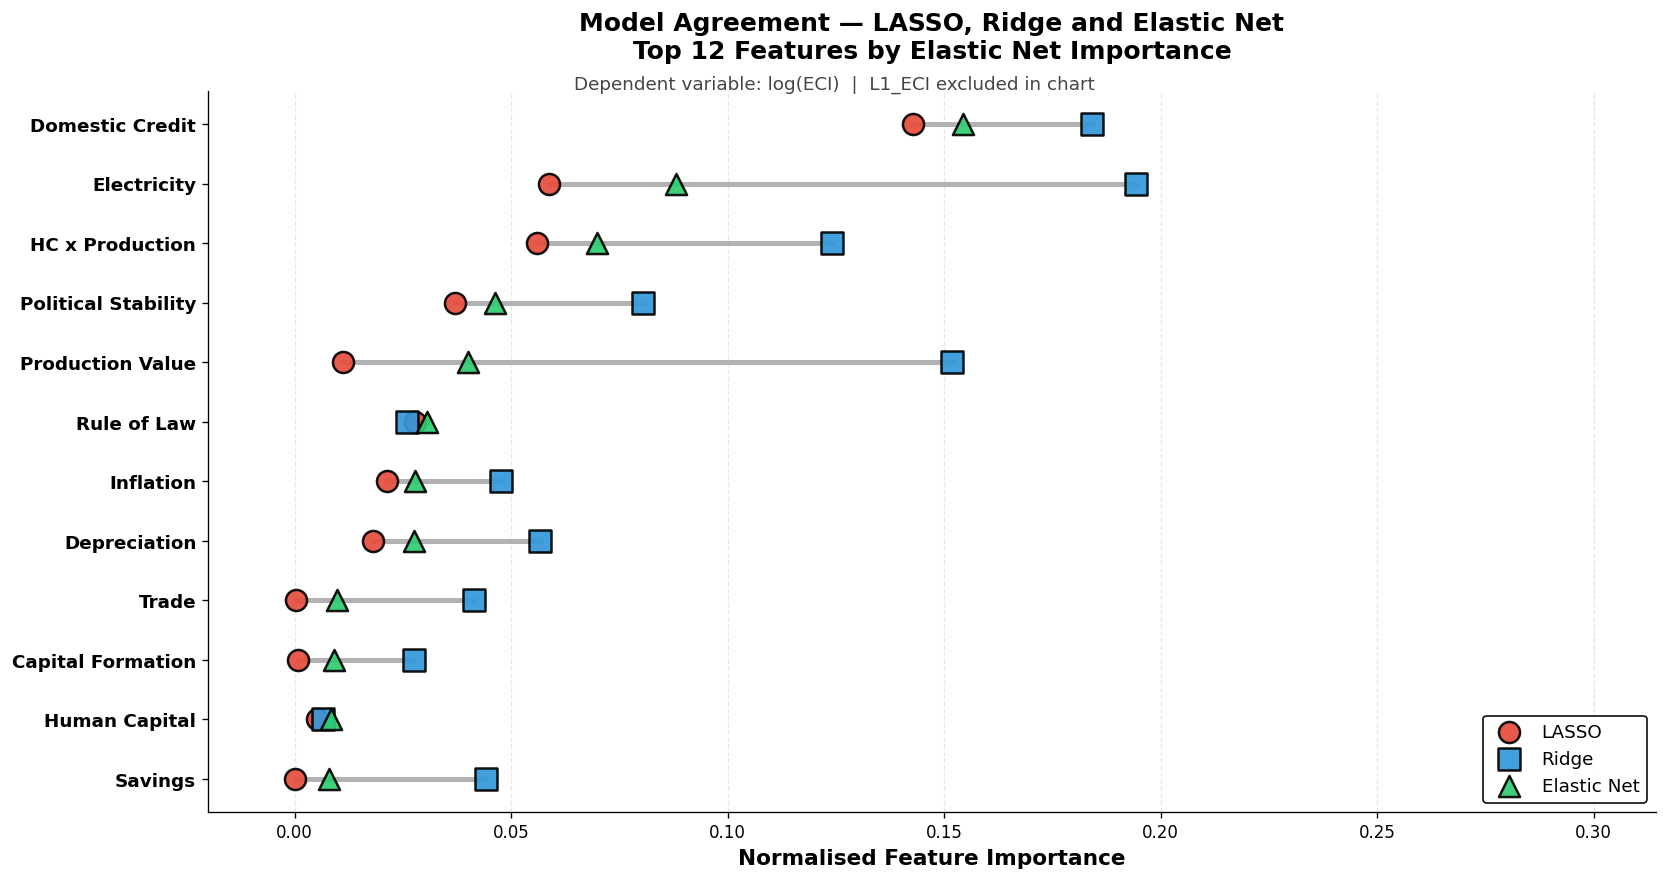

  ✓ Saved ModelAgreement_model2_resource_rich.{png,pdf}

[3/3] Plotting Random Forest importance...


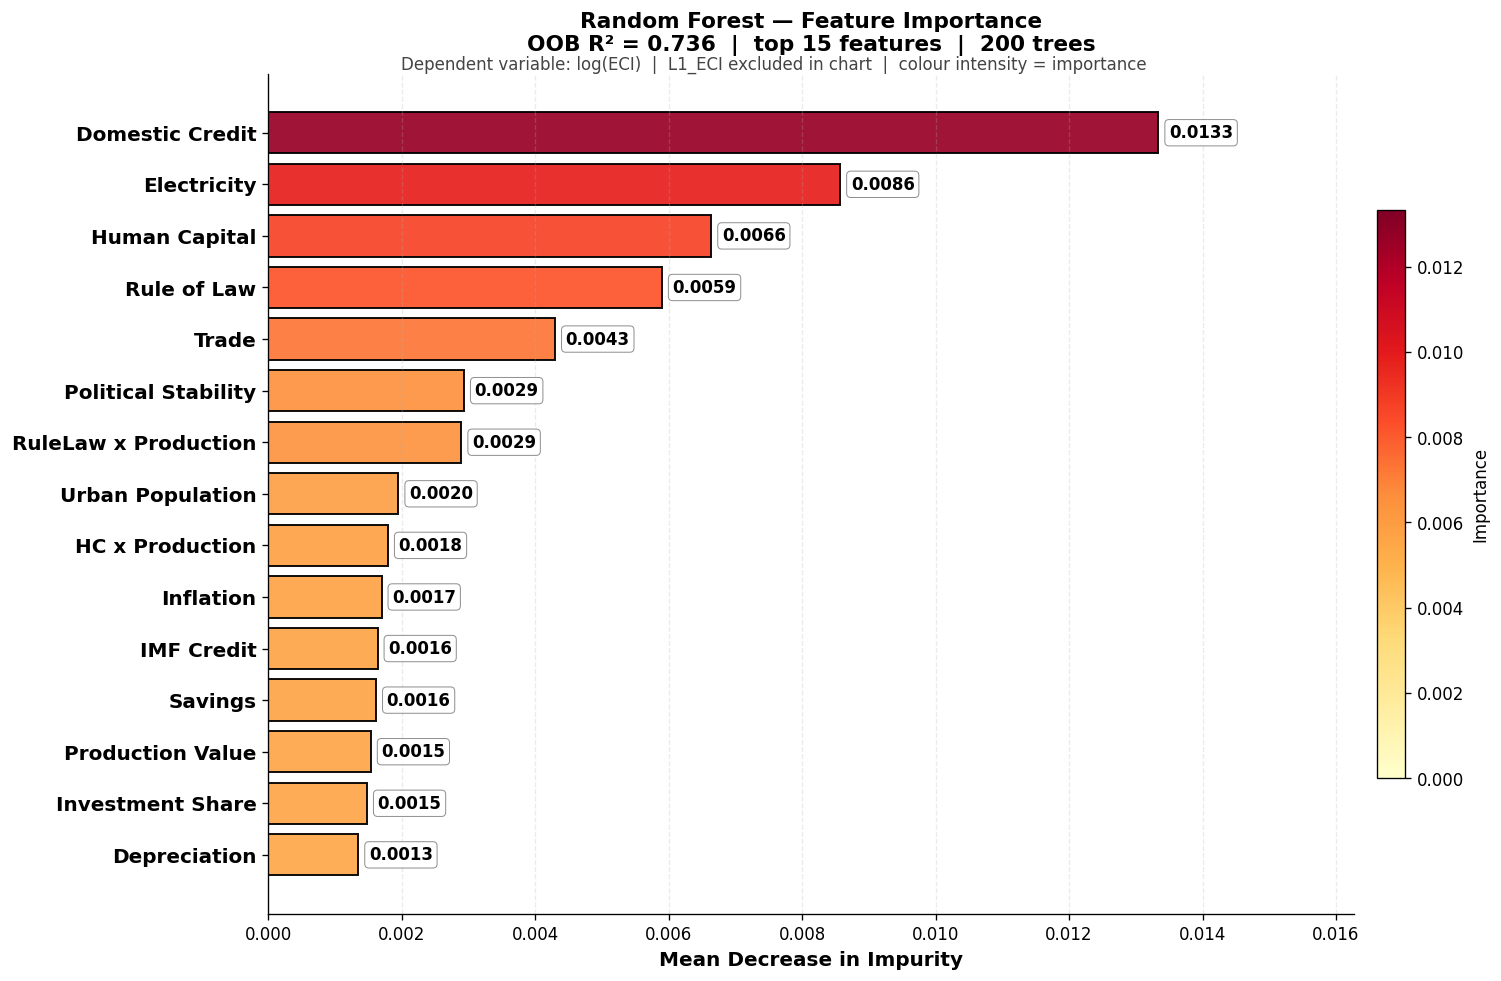

  ✓ Saved ..\figures\ml\RF_model2_resource_rich.{png,pdf}


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
import os
import warnings
warnings.filterwarnings('ignore')

# Output directory for figures
os.makedirs('..\\figures\\ml', exist_ok=True)

# ── 0. Load & prepare data ───────────────────────────────────────────────────
filter = True

GITHUB_BASE = "https://raw.githubusercontent.com/AyaanTigdikar/Capstone/main/MASTER/"
master = pd.read_csv(f"{GITHUB_BASE}Master.csv").drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Master: {len(master)} obs, {master['Country Code'].nunique()} countries")

df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])

resource_rich_countries = master[master['Year'] == 1995][
    master[master['Year'] == 1995]['Total natural resources rents (% of GDP)'] >= 5
]['Country Code'].unique()

if filter:
    df = df[df['Country Code'].isin(resource_rich_countries)]
df['Resource_Rich'] = df['Country Code'].isin(resource_rich_countries).astype(int)

# ECI lag
df['L1_ECI'] = df.groupby('Country Code')['Economic Complexity Index'].shift(1)
df = df.dropna()

# Interactions
df['HCI_x_ProductionValue']       = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index']   * df['Total_Production_Value']

# Feature lists
base_features = [
    'Total_Production_Value',
    'Human capital index',
    'Rule of law index',
    'Political stability — estimate',
    'Trade (% of GDP)',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)',
    'Landlocked',
    'Urban population (% of total population)',
    'Government revenue',
    'Capital depreciation rate',
    'Use of IMF credit (DOD, current US$)',
    'Real interest rate (%)',
    'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'L1_ECI'
]
all_features = base_features + ['HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue']

print(f"Total features: {len(all_features)} (18 base + 1 group + 2 interactions)")

# ── 1. Log transforms ────────────────────────────────────────────────────────
min_val = df['Economic Complexity Index'].min()
df['ECI_shifted'] = df['Economic Complexity Index'] - min_val + 1
df['Economic Complexity Index'] = np.log(df['ECI_shifted'])

min_val = df['L1_ECI'].min()
df['L1_ECI_shifted'] = df['L1_ECI'] - min_val + 1
df['L1_ECI'] = np.log(df['L1_ECI_shifted'])

log_features = [
    'Human capital index',
    'Total_Production_Value',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Government revenue',
    'Use of IMF credit (DOD, current US$)',
]
df[log_features] = np.log1p(df[log_features])
df[log_features] = df[log_features].replace([np.inf, -np.inf], np.nan)
df = df.dropna()
print(f"After transforms: {len(df)} obs")

# ── 2. Arrays — fit on full dataset ──────────────────────────────────────────
y = df['Economic Complexity Index'].values
X = df[all_features].copy()

print(f"Observations: {X.shape[0]} | Features: {X.shape[1]}")

# ── 3. Scale on full data ─────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X.values)
y_train = y

# ── 4. CV for alpha selection only (no held-out test set) ────────────────────
tscv = TimeSeriesSplit(n_splits=5, gap=1)

# ── 5. Train models on all data ───────────────────────────────────────────────
l1_ratios = [0.5]

lasso   = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge   = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(l1_ratio=l1_ratios, cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
rf      = RandomForestRegressor(
    n_estimators=200, max_depth=4, min_samples_leaf=10,
    random_state=42, n_jobs=-1, oob_score=True
).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}
print("\n✓ All models fitted on full dataset")
print(f"  Elastic Net  →  best l1_ratio: {elastic.l1_ratio_:.2f}  |  alpha: {elastic.alpha_:.4f}")
print(f"  LASSO        →  best alpha:    {lasso.alpha_:.4f}")
print(f"  Ridge        →  best alpha:    {ridge.alpha_:.4f}")
print(f"  RF OOB R²    →  {rf.oob_score_:.4f}")

# ── 6. In-sample fit metrics ──────────────────────────────────────────────────
perf_rows = []
for name, model in models.items():
    pred = model.predict(X_train)
    perf_rows.append({
        'Model':      name,
        'R²':  round(model.score(X_train, y_train), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_train, pred)), 4),
        'MAE':  round(mean_absolute_error(y_train, pred), 4),
    })

perf_df = pd.DataFrame(perf_rows).sort_values('R²', ascending=False).reset_index(drop=True)

# ── 7. VIF on full scaled data ────────────────────────────────────────────────
vif_data = pd.DataFrame({
    'Feature': all_features,
    'VIF':     [variance_inflation_factor(X_train, i) for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
high_vif = vif_data[vif_data['VIF'] > 10]


# ── 8. Normalised importance (min-max per model before averaging) ─────────────
def minmax(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo) if hi > lo else arr

all_importance = pd.DataFrame({'Feature': all_features})
feature_signs  = pd.DataFrame({'Feature': all_features})

for name, model in models.items():
    if name == 'Random Forest':
        raw = model.feature_importances_
        all_importance[name] = minmax(raw)
        feature_signs[name]  = 1.0
    else:
        raw = model.coef_
        all_importance[name] = minmax(np.abs(raw))
        feature_signs[name]  = np.sign(raw)

lin_cols = ['LASSO', 'Ridge', 'Elastic Net']
all_importance['Linear_Avg']  = all_importance[lin_cols].mean(axis=1)
all_importance['Overall_Avg'] = all_importance[['Linear_Avg', 'Random Forest']].mean(axis=1)
all_importance = all_importance.sort_values('Overall_Avg', ascending=False).reset_index(drop=True)

# ── 9. Signed coefficients ────────────────────────────────────────────────────
lin_models = {k: v for k, v in models.items() if k != 'Random Forest'}
signed = pd.DataFrame({'Feature': all_features})
for name, model in lin_models.items():
    signed[f'{name}_coef'] = model.coef_
signed['Avg_signed_coef'] = signed[[f'{n}_coef' for n in lin_models]].mean(axis=1)
signed['Avg_abs']         = signed['Avg_signed_coef'].abs()
signed = signed.sort_values('Avg_abs', ascending=False).reset_index(drop=True)

# ── Name mapping ──────────────────────────────────────────────────────────────
name_mapping = {
    'Human capital index':                                                   'Human Capital',
    'Rule of law index':                                                     'Rule of Law',
    'Political stability — estimate':                                        'Political Stability',
    'Trade (% of GDP)':                                                      'Trade',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP':   'Capital Formation',
    'Share of investment in GDP':                                            'Investment Share',
    'Domestic credit to private sector (% of GDP)':                         'Domestic Credit',
    'Landlocked':                                                            'Landlocked',
    'Urban population (% of total population)':                             'Urban Population',
    'Government revenue':                                                    'Gov Revenue',
    'Capital depreciation rate':                                             'Depreciation',
    'Use of IMF credit (DOD, current US$)':                                 'IMF Credit',
    'Real interest rate (%)':                                                'Interest Rate',
    'Inflation, consumer prices (annual %)':                                 'Inflation',
    'Access to electricity (% of population)':                              'Electricity',
    'Adjusted savings: gross savings (% of GNI)':                           'Savings',
    'Total_Production_Value':                                                'Production Value',
#    'Resource_Rich':                                                         'Resource Rich',
    'HCI_x_ProductionValue':                                                 'HC x Production',
    'RuleOfLaw_x_ProductionValue':                                           'RuleLaw x Production',
    'L1_ECI':                                                                'Lagged ECI',
}

def shorten_name(name):
    return name_mapping.get(name, name[:22])

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       120,
})

EXCLUDE = 'L1_ECI'   # excluded from all charts

# ── CHART 1: VIF ──────────────────────────────────────────────────────────────
print("\n[1/3] Plotting VIF chart...")

vif_plot = vif_data.copy()
vif_plot['Short'] = vif_plot['Feature'].apply(shorten_name)
vif_plot = vif_plot.sort_values('VIF', ascending=True).reset_index(drop=True)

bar_colors = ['#E74C3C' if v > 10 else '#3498DB' for v in vif_plot['VIF']]

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = np.arange(len(vif_plot))

ax.barh(y_pos, vif_plot['VIF'], color=bar_colors, alpha=0.85,
        edgecolor='black', linewidth=1.2)
ax.axvline(10, color='#E74C3C', linewidth=2, linestyle='--', alpha=0.8,
           label='VIF = 10 (concern threshold)')
ax.axvline(5,  color='#F39C12', linewidth=1.5, linestyle=':',  alpha=0.7,
           label='VIF = 5 (caution threshold)')

ax.set_yticks(y_pos)
ax.set_yticklabels(vif_plot['Short'], fontsize=11, fontweight='bold')
ax.set_xlabel('Variance Inflation Factor (VIF)', fontsize=12, fontweight='bold')
ax.set_title('Multicollinearity Diagnostics — VIF by Feature',
             fontsize=14, fontweight='bold', pad=14)
plt.figtext(0.5, 0.86, 'VIF > 10 flagged in red  |  all features computed on full scaled dataset',
            ha='center', fontsize=10, color='#444')

x_max_vif = vif_plot['VIF'].max()
for i, val in enumerate(vif_plot['VIF']):
    ax.text(min(val - 0.15, 10.8), i, f'{val:.1f}',
            va='center', ha='right', fontsize=9, fontweight='bold',
            color='black')

ax.set_xlim(0, 11)
ax.legend(fontsize=10, loc='lower right', framealpha=0.95)
ax.grid(axis='x', alpha=0.25, linestyle='--')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('..\\figures\\ml\\VIF_model2_resource_rich.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('..\\figures\\ml\\VIF_model2_resource_rich.pdf', bbox_inches='tight')
plt.show()
print("  ✓ Saved ..\\figures\\ml\\VIF_model2_resource_rich.{png,pdf}")

# ── CHART 2: 3-Panel Coefficient Comparison (LASSO, Ridge, Elastic Net) ───────
print("\n[4/5] Plotting 3-panel coefficient comparison...")

fig, axes = plt.subplots(1, 3, figsize=(22, 12))

for idx, model_name in enumerate(['LASSO', 'Ridge', 'Elastic Net']):
    ax = axes[idx]

    signed_vals = models[model_name].coef_.copy()
    abs_vals    = np.abs(signed_vals)

    exclude_idx = all_features.index(EXCLUDE) if EXCLUDE in all_features else None
    if exclude_idx is not None:
        abs_vals[exclude_idx] = -np.inf

    top15_idx  = np.argsort(abs_vals)[::-1][:15]
    top15_feat = [all_features[i] for i in top15_idx]
    top15_vals = signed_vals[top15_idx]

    colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in top15_vals]
    labels = [shorten_name(f) for f in top15_feat]
    y_pos  = np.arange(len(top15_feat))

    ax.barh(y_pos, top15_vals, color=colors, alpha=0.85,
            edgecolor='black', linewidth=1.5)
    ax.axvline(0, color='black', linewidth=2.5, alpha=0.8, zorder=0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    r2        = perf_df[perf_df['Model'] == model_name]['R²'].values[0]
    n_nonzero = int(np.sum(models[model_name].coef_ != 0))
    ax.set_title(f'{model_name}\nR² = {r2:.3f}  |  {n_nonzero} features selected',
                 fontsize=13, fontweight='bold', pad=12)

    x_max = max(abs(top15_vals)) if len(top15_vals) else 1
    for i, val in enumerate(top15_vals):
        if abs(val) > 0.005:
            x_pos = abs(val) + x_max * 0.03 if val > 0 else x_max * 0.03
            ax.text(x_pos, i, f'{val:+.3f}',
                    va='center', ha='left', fontsize=9.5, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              alpha=0.95, edgecolor='gray', linewidth=0.8))

fig.legend(
    handles=[
        Patch(facecolor='#2ECC71', label='Positive', alpha=0.85, edgecolor='black', linewidth=1.5),
        Patch(facecolor='#E74C3C', label='Negative', alpha=0.85, edgecolor='black', linewidth=1.5),
    ],
    loc='lower center', bbox_to_anchor=(0.5, -0.02),
    ncol=2, fontsize=13, framealpha=0.98, edgecolor='black', fancybox=True
)

plt.suptitle('Standardised Coefficients — LASSO, Ridge and Elastic Net',
             fontsize=18, fontweight='bold', y=0.98)
plt.figtext(0.5, 0.94,
            'Dependent variable: log(ECI)  |  L1_ECI excluded in chart  |  top 15 features',
            ha='center', fontsize=12, color='#444')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('..\\figures\\ml\\Coef_Comparison_model2_resource_rich.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('..\\figures\\ml\\Coef_Comparison_model2_resource_rich.pdf', bbox_inches='tight')
plt.show()
print("  ✓ Saved Coef_Comparison_model2_resource_rich.{png,pdf}")


# ── CHART 3: Model Agreement — Dot-and-Range Plot (Feature Importance) ────────
print("\n[5/5] Plotting model agreement chart...")

imp_df = all_importance[all_importance['Feature'] != EXCLUDE].copy()
imp_df['EN_abs'] = imp_df['Elastic Net']
top12  = imp_df.sort_values('EN_abs', ascending=False).head(12).reset_index(drop=True)
top12['Short'] = top12['Feature'].apply(shorten_name)

fig, ax = plt.subplots(figsize=(14, 8))
y_pos = np.arange(len(top12))

for i, row in top12.iterrows():
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net']]

    ax.plot([min(vals), max(vals)], [i, i],
            color='#555555', alpha=0.45, linewidth=3, zorder=1)

    ax.scatter(row['LASSO'],       i, marker='o', s=160, alpha=0.92,
               color='#E74C3C', edgecolor='black', linewidth=1.5, zorder=3,
               label='LASSO'       if i == 0 else '')
    ax.scatter(row['Ridge'],       i, marker='s', s=160, alpha=0.92,
               color='#3498DB', edgecolor='black', linewidth=1.5, zorder=3,
               label='Ridge'       if i == 0 else '')
    ax.scatter(row['Elastic Net'], i, marker='^', s=160, alpha=0.92,
               color='#2ECC71', edgecolor='black', linewidth=1.5, zorder=3,
               label='Elastic Net' if i == 0 else '')

ax.set_yticks(y_pos)
ax.set_yticklabels(top12['Short'], fontsize=11, fontweight='bold')
ax.set_xlabel('Normalised Feature Importance', fontsize=13, fontweight='bold')
ax.set_title('Model Agreement — LASSO, Ridge and Elastic Net\nTop 12 Features by Elastic Net Importance',
             fontsize=15, fontweight='bold', pad=20)
plt.figtext(0.5, 0.83,
            'Dependent variable: log(ECI)  |  L1_ECI excluded in chart',
            ha='center', fontsize=11, color='#444')
ax.invert_yaxis()
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, edgecolor='black', ncol=1)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tight x-axis: just enough room for the value labels
x_max_val = max(top12[['LASSO', 'Ridge', 'Elastic Net']].max())
ax.set_xlim(-0.02, x_max_val + 0.12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('..\\figures\\ml\\ModelAgreement_model2_resource_rich.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('..\\figures\\ml\\ModelAgreement_model2_resource_rich.pdf', bbox_inches='tight')
plt.show()
print("  ✓ Saved ModelAgreement_model2_resource_rich.{png,pdf}")

# ── CHART 4: Random Forest feature importance ──────────────────────────────────
print("\n[3/3] Plotting Random Forest importance...")

rf_imp = pd.DataFrame({'Feature': all_features, 'Importance': rf.feature_importances_})
rf_top = (
    rf_imp[rf_imp['Feature'] != EXCLUDE]
    .sort_values('Importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

norm_vals  = rf_top['Importance'] / rf_top['Importance'].max()
cmap       = plt.cm.YlOrRd
bar_colors = [cmap(0.35 + 0.60 * v) for v in norm_vals]
y_pos      = np.arange(len(rf_top))

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(y_pos, rf_top['Importance'], color=bar_colors,
        edgecolor='black', linewidth=1.2, alpha=0.92)
ax.set_yticks(y_pos)
ax.set_yticklabels([shorten_name(f) for f in rf_top['Feature']],
                   fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.set_xlim(right=rf_top['Importance'].max() * 1.22)

x_max_rf = rf_top['Importance'].max()
for i, val in enumerate(rf_top['Importance']):
    ax.text(val + x_max_rf * 0.012, i, f'{val:.4f}',
            va='center', ha='left', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      alpha=0.88, edgecolor='gray', linewidth=0.6))

ax.set_title(
    f'Random Forest — Feature Importance\n'
    f'OOB R² = {rf.oob_score_:.3f}  |  top 15 features  |  200 trees',
    fontsize=13, fontweight='bold', pad=14
)
plt.figtext(0.5, 0.85,
            'Dependent variable: log(ECI)  |  L1_ECI excluded in chart  |  colour intensity = importance',
            ha='center', fontsize=10, color='#444')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=x_max_rf))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label('Importance', fontsize=10)

plt.tight_layout(rect=[0, 0, 0.97, 0.92])
plt.savefig('..\\figures\\ml\\RF_model2_resource_rich.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('..\\figures\\ml\\RF_model2_resource_rich.pdf', bbox_inches='tight')
plt.show()
print("  ✓ Saved ..\\figures\\ml\\RF_model2_resource_rich.{png,pdf}")



── Building summary table...

── Coefficient Summary Table ───────────────────────────────────────────
Feature                     LASSO    Ridge    E-Net   L-Imp   R-Imp  EN-Imp    VIF  L-Sel EN-Sel
───────────────────────────────────────────────────────────────────────────────────────────────
Domestic Credit            +0.023   +0.028   +0.024   0.143   0.184   0.154   2.98      ✓      ✓
Electricity                +0.010   +0.030   +0.014   0.059   0.194   0.088   5.20      ✓      ✓
HC x Production            +0.009   +0.020   +0.011   0.056   0.124   0.070   5.40      ✓      ✓
Political Stability        +0.006   +0.013   +0.007   0.037   0.080   0.046   2.20      ✓      ✓
Production Value           -0.002   -0.024   -0.006   0.011   0.152   0.040   2.85      ✓      ✓
Rule of Law                +0.004   +0.005   +0.005   0.028   0.026   0.031   2.32      ✓      ✓
Inflation                  -0.003   -0.009   -0.004   0.021   0.048   0.028   1.16      ✓      ✓
Depreciation            

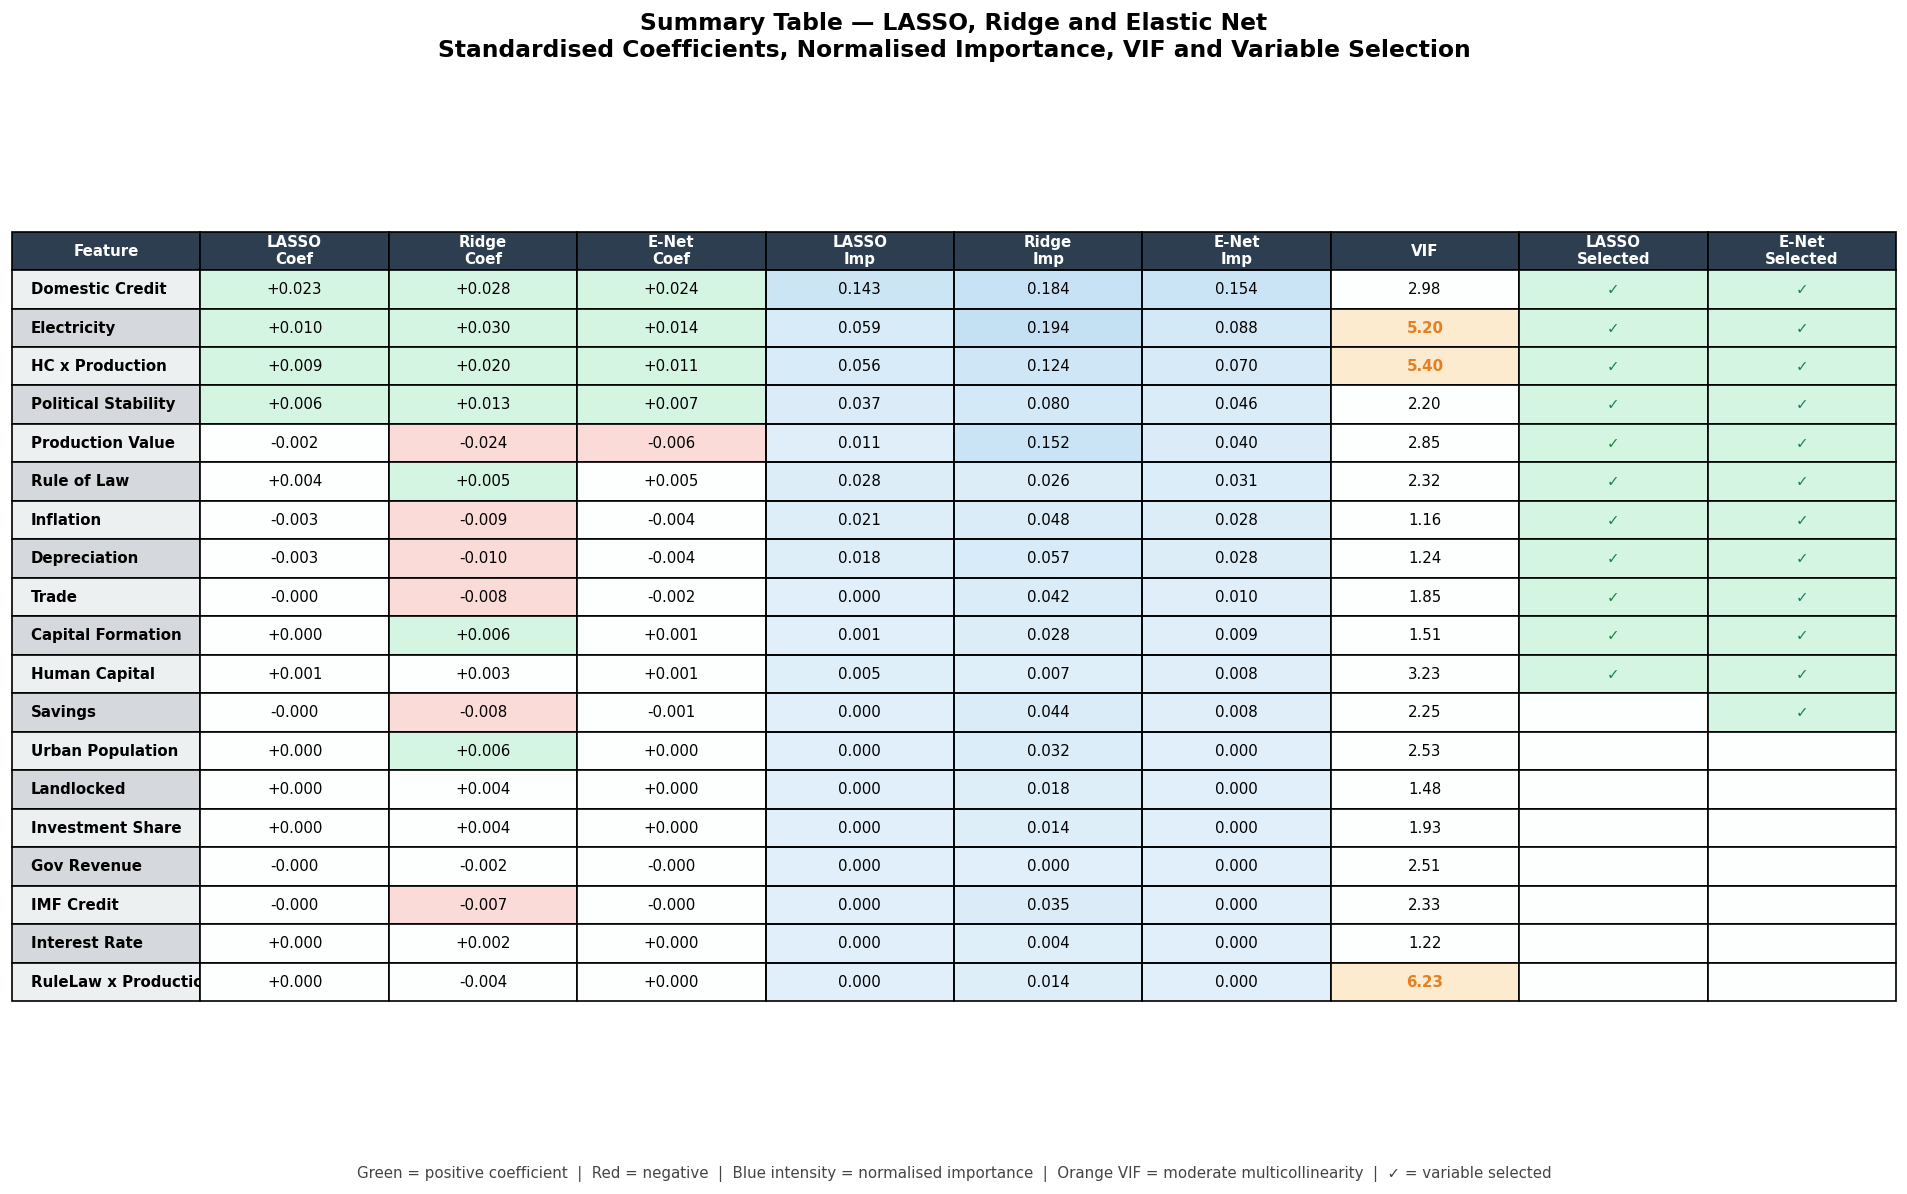

  ✓ Saved SummaryTable_model2_resource_rich.{png,pdf}


In [49]:
# ── SUMMARY TABLE: LASSO, Ridge and Elastic Net Coefficients ─────────────────
print("\n── Building summary table...")

# Signed coefficients for all linear models
table = pd.DataFrame({'Feature': all_features})
for name, model in lin_models.items():
    table[name] = model.coef_

# Add normalised importance
for name in ['LASSO', 'Ridge', 'Elastic Net']:
    table[f'{name}_Imp'] = all_importance.set_index('Feature')[name].reindex(all_features).values

# Add VIF
table = table.merge(vif_data, on='Feature')

# Add LASSO selection marker (non-zero = selected)
table['LASSO_Selected']       = (table['LASSO']       != 0).astype(int)
table['Elastic Net_Selected'] = (table['Elastic Net'] != 0).astype(int)

# Exclude L1_ECI from display, sort by |Elastic Net coef|
table = (
    table[table['Feature'] != EXCLUDE]
    .assign(sort_key=lambda d: d['Elastic Net'].abs())
    .sort_values('sort_key', ascending=False)
    .drop(columns='sort_key')
    .reset_index(drop=True)
)
table['Feature'] = table['Feature'].apply(shorten_name)

# ── Print to console ──────────────────────────────────────────────────────────
print("\n── Coefficient Summary Table ───────────────────────────────────────────")
print(f"{'Feature':<24} {'LASSO':>8} {'Ridge':>8} {'E-Net':>8} "
      f"{'L-Imp':>7} {'R-Imp':>7} {'EN-Imp':>7} {'VIF':>6} {'L-Sel':>6} {'EN-Sel':>6}")
print("─" * 95)
for _, row in table.iterrows():
    print(f"{row['Feature']:<24} "
          f"{row['LASSO']:>+8.3f} "
          f"{row['Ridge']:>+8.3f} "
          f"{row['Elastic Net']:>+8.3f} "
          f"{row['LASSO_Imp']:>7.3f} "
          f"{row['Ridge_Imp']:>7.3f} "
          f"{row['Elastic Net_Imp']:>7.3f} "
          f"{row['VIF']:>6.2f} "
          f"{'✓' if row['LASSO_Selected'] else '':>6} "
          f"{'✓' if row['Elastic Net_Selected'] else '':>6}")

# ── Save to CSV ───────────────────────────────────────────────────────────────
table.to_csv('coefficient_summary_table.csv', index=False)
print("\n✓ Saved: coefficient_summary_table.csv")

# ── CHART: Heatmap-style summary table ───────────────────────────────────────
print("\n── Plotting summary table chart...")

import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

col_labels = [
    'Feature',
    'LASSO\nCoef', 'Ridge\nCoef', 'E-Net\nCoef',
    'LASSO\nImp', 'Ridge\nImp', 'E-Net\nImp',
    'VIF',
    'LASSO\nSelected', 'E-Net\nSelected'
]

# Build cell values
cell_vals = []
for _, row in table.iterrows():
    cell_vals.append([
        row['Feature'],
        f"{row['LASSO']:+.3f}",
        f"{row['Ridge']:+.3f}",
        f"{row['Elastic Net']:+.3f}",
        f"{row['LASSO_Imp']:.3f}",
        f"{row['Ridge_Imp']:.3f}",
        f"{row['Elastic Net_Imp']:.3f}",
        f"{row['VIF']:.2f}",
        '✓' if row['LASSO_Selected']       else '',
        '✓' if row['Elastic Net_Selected'] else '',
    ])

tbl = ax.table(
    cellText=cell_vals,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.6)

# ── Cell colouring ────────────────────────────────────────────────────────────
# Coefficient columns: green = positive, red = negative, white = zero
coef_cols  = {1: 'LASSO', 2: 'Ridge', 3: 'Elastic Net'}
sel_cols   = {8: 'LASSO_Selected', 9: 'Elastic Net_Selected'}
vif_col    = 7

for row_idx, (_, row) in enumerate(table.iterrows(), start=1):
    # Header row style
    for col_idx in range(len(col_labels)):
        cell = tbl[0, col_idx]
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold', fontsize=9)

    # Feature column
    tbl[row_idx, 0].set_facecolor('#ECF0F1')
    tbl[row_idx, 0].set_text_props(fontweight='bold', ha='left')

    # Coefficient columns — green/red/neutral
    for col_idx, col_name in coef_cols.items():
        val = row[col_name]
        if val > 0.005:
            color = '#D5F5E3'   # light green
        elif val < -0.005:
            color = '#FADBD8'   # light red
        else:
            color = '#FDFEFE'   # near-white (zero / shrunk)
        tbl[row_idx, col_idx].set_facecolor(color)

    # Importance columns — intensity proportional to value
    for col_idx, imp_col in [(4, 'LASSO_Imp'), (5, 'Ridge_Imp'), (6, 'Elastic Net_Imp')]:
        val     = row[imp_col]
        alpha   = 0.15 + 0.70 * val   # scale 0.15–0.85
        color   = mcolors.to_rgba('#3498DB', alpha=alpha)
        tbl[row_idx, col_idx].set_facecolor(color)

    # VIF column — orange if > 5, normal otherwise
    vif_val = row['VIF']
    if vif_val > 10:
        tbl[row_idx, vif_col].set_facecolor('#FADBD8')
        tbl[row_idx, vif_col].set_text_props(color='#C0392B', fontweight='bold')
    elif vif_val > 5:
        tbl[row_idx, vif_col].set_facecolor('#FDEBD0')
        tbl[row_idx, vif_col].set_text_props(color='#E67E22', fontweight='bold')
    else:
        tbl[row_idx, vif_col].set_facecolor('#FDFEFE')

    # Selection columns — green tick or blank
    for col_idx, sel_col in sel_cols.items():
        if row[sel_col]:
            tbl[row_idx, col_idx].set_facecolor('#D5F5E3')
            tbl[row_idx, col_idx].set_text_props(color='#1E8449', fontweight='bold')
        else:
            tbl[row_idx, col_idx].set_facecolor('#FDFEFE')

    # Alternating row shading on feature column
    if row_idx % 2 == 0:
        tbl[row_idx, 0].set_facecolor('#D5D8DC')

ax.set_title(
    'Summary Table — LASSO, Ridge and Elastic Net\n'
    'Standardised Coefficients, Normalised Importance, VIF and Variable Selection',
    fontsize=14, fontweight='bold', pad=16, y=0.98
)
plt.figtext(
    0.5, 0.01,
    'Green = positive coefficient  |  Red = negative  |  Blue intensity = normalised importance  '
    '|  Orange VIF = moderate multicollinearity  |  ✓ = variable selected',
    ha='center', fontsize=9, color='#444'
)

plt.tight_layout()
plt.savefig('..\\figures\\ml\\SummaryTable_model2_resource_rich.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('..\\figures\\ml\\SummaryTable_model2_resource_rich.pdf', bbox_inches='tight')
plt.show()
print("  ✓ Saved SummaryTable_model2_resource_rich.{png,pdf}")

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')


# ── Robust chart export + inline display ──────────────────────────────────────
def save_chart(fig, path_no_ext, width=1100, height=700):
    """Display inline in notebook, then save .html and attempt .png."""
    fig.show()

    fig.write_html(f"{path_no_ext}.html", config=WRITE_CONFIG)
    print(f"  ✓ {path_no_ext}.html")

    for engine in ["kaleido", "orca"]:
        try:
            fig.write_image(f"{path_no_ext}.png", width=width, height=height,
                            scale=3, engine=engine)
            print(f"  ✓ {path_no_ext}.png ({engine})")
            return
        except Exception:
            pass

    print(f"  ⚠ PNG export skipped (kaleido not available). HTML saved.")

# ── Style system (matching user's existing charts) ────────────────────────────
STYLE = {
    'font_family': 'IBM Plex Sans, -apple-system, BlinkMacSystemFont, sans-serif',
    'tick_size': 11,
    'axis_title_size': 13,
    'legend_size': 11,
    'annotation_size': 10,
    'title_color': '#1a2744',
    'template': 'plotly_white',
    'plot_bg': '#ffffff',
    'paper_bg': '#ffffff',
    'chart_height': 550,
    'chart_height_small': 420,
    'chart_height_tall': 700,
    'margin': dict(l=60, r=40, t=10, b=50),
    'margin_bar': dict(l=160, r=130, t=10, b=50),
    'grid_color': '#e5e7eb',
    'grid_width': 0.5,
    'zero_line_color': '#c9cfd6',
}
WRITE_CONFIG = {'displayModeBar': False, 'responsive': True}

# Palette drawn from the user's existing colour system
PALETTE = {
    'blue':       '#4a6fa5',
    'red':        '#c23a3a',
    'green':      '#2e7d4a',
    'orange':     '#d4853b',
    'light_blue': '#7a9dc4',
    'light_red':  '#d46b6b',
    'light_green':'#5aa87a',
    'dark':       '#3d4f5f',
    'grey':       '#999999',
    'gold':       '#e6b980',
}

def base_layout(**kwargs):
    layout = dict(
        template=STYLE['template'],
        plot_bgcolor=STYLE['plot_bg'],
        paper_bgcolor=STYLE['paper_bg'],
        font=dict(family=STYLE['font_family'], size=STYLE['tick_size'],
                  color=STYLE['title_color']),
        margin=STYLE['margin'],
        height=STYLE['chart_height'],
    )
    layout.update(kwargs)
    return layout

# ── Output directory ──────────────────────────────────────────────────────────
OUT = os.path.join('..', 'figures', 'ml')
os.makedirs(OUT, exist_ok=True)

# ── 0. Load & prepare data ───────────────────────────────────────────────────
filter_flag = True

GITHUB_BASE = "https://raw.githubusercontent.com/AyaanTigdikar/Capstone/main/MASTER/"
master = pd.read_csv(f"{GITHUB_BASE}Master.csv").drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Master: {len(master)} obs, {master['Country Code'].nunique()} countries")

df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])

resource_rich_countries = master[master['Year'] == 1995][
    master[master['Year'] == 1995]['Total natural resources rents (% of GDP)'] >= 5
]['Country Code'].unique()

if filter_flag:
    df = df[df['Country Code'].isin(resource_rich_countries)]
df['Resource_Rich'] = df['Country Code'].isin(resource_rich_countries).astype(int)

df['L1_ECI'] = df.groupby('Country Code')['Economic Complexity Index'].shift(1)
df = df.dropna()

df['HCI_x_ProductionValue']       = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index']   * df['Total_Production_Value']

base_features = [
    'Total_Production_Value',
    'Human capital index',
    'Rule of law index',
    'Political stability — estimate',
    'Trade (% of GDP)',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)',
    'Landlocked',
    'Urban population (% of total population)',
    'Government revenue',
    'Capital depreciation rate',
    'Use of IMF credit (DOD, current US$)',
    'Real interest rate (%)',
    'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'L1_ECI'
]
all_features = base_features + ['HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue']
print(f"Total features: {len(all_features)} (18 base + 1 group + 2 interactions)")

# ── 1. Log transforms ────────────────────────────────────────────────────────
min_val = df['Economic Complexity Index'].min()
df['ECI_shifted'] = df['Economic Complexity Index'] - min_val + 1
df['Economic Complexity Index'] = np.log(df['ECI_shifted'])

min_val = df['L1_ECI'].min()
df['L1_ECI_shifted'] = df['L1_ECI'] - min_val + 1
df['L1_ECI'] = np.log(df['L1_ECI_shifted'])

log_features = [
    'Human capital index',
    'Total_Production_Value',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Government revenue',
    'Use of IMF credit (DOD, current US$)',
]
df[log_features] = np.log1p(df[log_features])
df[log_features] = df[log_features].replace([np.inf, -np.inf], np.nan)
df = df.dropna()
print(f"After transforms: {len(df)} obs")

# ── 2. Arrays ─────────────────────────────────────────────────────────────────
y = df['Economic Complexity Index'].values
X = df[all_features].copy()
print(f"Observations: {X.shape[0]} | Features: {X.shape[1]}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X.values)
y_train = y

tscv = TimeSeriesSplit(n_splits=5, gap=1)

# ── 3. Train models ──────────────────────────────────────────────────────────
lasso   = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge   = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(l1_ratio=[0.5], cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
rf      = RandomForestRegressor(
    n_estimators=200, max_depth=4, min_samples_leaf=10,
    random_state=42, n_jobs=-1, oob_score=True
).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}
print("\n✓ All models fitted")
print(f"  Elastic Net  →  l1_ratio: {elastic.l1_ratio_:.2f}  |  alpha: {elastic.alpha_:.4f}")
print(f"  LASSO        →  alpha:    {lasso.alpha_:.4f}")
print(f"  Ridge        →  alpha:    {ridge.alpha_:.4f}")
print(f"  RF OOB R²    →  {rf.oob_score_:.4f}")

# ── 4. Performance table ─────────────────────────────────────────────────────
perf_rows = []
for name, model in models.items():
    pred = model.predict(X_train)
    perf_rows.append({
        'Model': name,
        'R²': round(model.score(X_train, y_train), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_train, pred)), 4),
        'MAE': round(mean_absolute_error(y_train, pred), 4),
    })
perf_df = pd.DataFrame(perf_rows).sort_values('R²', ascending=False).reset_index(drop=True)
print("\n", perf_df.to_string(index=False))

# ── 5. VIF ────────────────────────────────────────────────────────────────────
vif_data = pd.DataFrame({
    'Feature': all_features,
    'VIF': [variance_inflation_factor(X_train, i) for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

# ── 6. Importance ─────────────────────────────────────────────────────────────
def minmax(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo) if hi > lo else arr

all_importance = pd.DataFrame({'Feature': all_features})
for name, model in models.items():
    if name == 'Random Forest':
        all_importance[name] = minmax(model.feature_importances_)
    else:
        all_importance[name] = minmax(np.abs(model.coef_))

# ── Name mapping ──────────────────────────────────────────────────────────────
name_mapping = {
    'Human capital index':                                                   'Human Capital',
    'Rule of law index':                                                     'Rule of Law',
    'Political stability — estimate':                                        'Political Stability',
    'Trade (% of GDP)':                                                      'Trade',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP':   'Capital Formation',
    'Share of investment in GDP':                                            'Investment Share',
    'Domestic credit to private sector (% of GDP)':                         'Domestic Credit',
    'Landlocked':                                                            'Landlocked',
    'Urban population (% of total population)':                             'Urban Population',
    'Government revenue':                                                    'Gov Revenue',
    'Capital depreciation rate':                                             'Depreciation',
    'Use of IMF credit (DOD, current US$)':                                 'IMF Credit',
    'Real interest rate (%)':                                                'Interest Rate',
    'Inflation, consumer prices (annual %)':                                 'Inflation',
    'Access to electricity (% of population)':                              'Electricity',
    'Adjusted savings: gross savings (% of GNI)':                           'Savings',
    'Total_Production_Value':                                                'Production Value',
    'HCI_x_ProductionValue':                                                 'HC × Production',
    'RuleOfLaw_x_ProductionValue':                                           'RuleLaw × Production',
    'L1_ECI':                                                                'Lagged ECI',
}
def shorten(name):
    return name_mapping.get(name, name[:22])

EXCLUDE = 'L1_ECI'

# ══════════════════════════════════════════════════════════════════════════════
# CHART 1: VIF
# ══════════════════════════════════════════════════════════════════════════════
print("\n[1/4] VIF chart...")

vif_plot = vif_data.copy()
vif_plot['Short'] = vif_plot['Feature'].apply(shorten)
vif_plot = vif_plot.sort_values('VIF', ascending=True).reset_index(drop=True)

colors_vif = [PALETTE['red'] if v > 10 else PALETTE['blue'] for v in vif_plot['VIF']]

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    y=vif_plot['Short'],
    x=vif_plot['VIF'],
    orientation='h',
    marker=dict(color=colors_vif, line=dict(color='#1a2744', width=0.5)),
    text=[f'{v:.1f}' for v in vif_plot['VIF']],
    textposition='outside',
    textfont=dict(size=STYLE['annotation_size'], color=STYLE['title_color']),
))

# Threshold lines
fig1.add_vline(x=10, line=dict(color=PALETTE['red'], width=2, dash='dash'),
               annotation_text='VIF = 10', annotation_position='top right',
               annotation_font=dict(size=STYLE['annotation_size'], color=PALETTE['red']))
fig1.add_vline(x=5, line=dict(color=PALETTE['orange'], width=1.5, dash='dot'),
               annotation_text='VIF = 5', annotation_position='top right',
               annotation_font=dict(size=STYLE['annotation_size'], color=PALETTE['orange']))

fig1.update_layout(**base_layout(
    height=STYLE['chart_height_tall'],
    margin=STYLE['margin_bar'],
    xaxis=dict(
        title=dict(text='Variance Inflation Factor (VIF)', font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        range=[0, max(vif_plot['VIF'].max() * 1.15, 12)],
    ),
    yaxis=dict(
        tickfont=dict(size=STYLE['tick_size']),
    ),
    showlegend=False,
))

save_chart(fig1, os.path.join(OUT, 'VIF_model2_resource_rich'), width=1100, height=700)

# ══════════════════════════════════════════════════════════════════════════════
# CHART 2: 3-Panel Coefficient Comparison
# ══════════════════════════════════════════════════════════════════════════════
print("\n[2/4] 3-panel coefficient comparison...")

model_names_lin = ['LASSO', 'Ridge', 'Elastic Net']

fig2 = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        f"<b>{n}</b><br><span style='font-size:11px;color:#666'>R² = {perf_df[perf_df['Model']==n]['R²'].values[0]:.3f} | "
        f"{int(np.sum(models[n].coef_ != 0))} features</span>"
        for n in model_names_lin
    ],
    horizontal_spacing=0.08,
)

for col_idx, model_name in enumerate(model_names_lin, 1):
    signed_vals = models[model_name].coef_.copy()
    abs_vals    = np.abs(signed_vals)

    exclude_idx = all_features.index(EXCLUDE) if EXCLUDE in all_features else None
    if exclude_idx is not None:
        abs_vals[exclude_idx] = -np.inf

    top15_idx  = np.argsort(abs_vals)[::-1][:15]
    top15_feat = [all_features[i] for i in top15_idx]
    top15_vals = signed_vals[top15_idx]

    colors = [PALETTE['green'] if v > 0 else PALETTE['red'] for v in top15_vals]
    labels = [shorten(f) for f in top15_feat]

    # Reverse for plotly (bottom-to-top)
    labels_r = labels[::-1]
    vals_r   = top15_vals[::-1]
    colors_r = colors[::-1]

    fig2.add_trace(go.Bar(
        y=labels_r,
        x=vals_r,
        orientation='h',
        marker=dict(color=colors_r, line=dict(color='#1a2744', width=0.5)),
        text=[f'{v:+.3f}' if abs(v) > 0.005 else '' for v in vals_r],
        textposition='outside',
        textfont=dict(size=9, color=STYLE['title_color']),
        showlegend=False,
    ), row=1, col=col_idx)

    # Zero line
    fig2.add_vline(x=0, line=dict(color=STYLE['zero_line_color'], width=2),
                   row=1, col=col_idx)

    fig2.update_xaxes(
        title_text='Coefficient' if col_idx == 2 else '',
        title_font=dict(size=STYLE['axis_title_size']),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        row=1, col=col_idx,
    )
    fig2.update_yaxes(
        tickfont=dict(size=STYLE['tick_size']),
        row=1, col=col_idx,
    )

# Legend via invisible traces
fig2.add_trace(go.Bar(y=[None], x=[None], marker_color=PALETTE['green'],
                       name='Positive', showlegend=True))
fig2.add_trace(go.Bar(y=[None], x=[None], marker_color=PALETTE['red'],
                       name='Negative', showlegend=True))

fig2.update_layout(**base_layout(
    height=STYLE['chart_height_tall'],
    width=1600,
    margin=dict(l=160, r=80, t=70, b=100),
    legend=dict(
        orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5,
        font=dict(size=STYLE['legend_size']),
    ),
))

save_chart(fig2, os.path.join(OUT, 'Coef_Comparison_model2_resource_rich'), width=1600, height=700)

# ══════════════════════════════════════════════════════════════════════════════
# CHART 3: Model Agreement — Dot-and-Range
# ══════════════════════════════════════════════════════════════════════════════
print("\n[3/4] Model agreement chart...")

imp_df = all_importance[all_importance['Feature'] != EXCLUDE].copy()
imp_df['EN_abs'] = imp_df['Elastic Net']
top12  = imp_df.sort_values('EN_abs', ascending=False).head(12).reset_index(drop=True)
top12['Short'] = top12['Feature'].apply(shorten)

# Reverse for plotly (bottom-to-top)
top12_r = top12.iloc[::-1].reset_index(drop=True)

fig3 = go.Figure()

# Range lines
for _, row in top12_r.iterrows():
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net']]
    fig3.add_trace(go.Scatter(
        x=[min(vals), max(vals)],
        y=[row['Short'], row['Short']],
        mode='lines',
        line=dict(color='#aab0b8', width=3),
        showlegend=False,
        hoverinfo='skip',
    ))

# Model dots
dot_config = [
    ('LASSO',       'circle',       PALETTE['red']),
    ('Ridge',       'square',       PALETTE['blue']),
    ('Elastic Net', 'triangle-up',  PALETTE['green']),
]
for model_name, symbol, color in dot_config:
    fig3.add_trace(go.Scatter(
        x=top12_r[model_name],
        y=top12_r['Short'],
        mode='markers',
        marker=dict(symbol=symbol, size=12, color=color,
                    line=dict(color='#1a2744', width=1)),
        name=model_name,
        hovertemplate='%{y}: %{x:.3f}<extra>' + model_name + '</extra>',
    ))

fig3.update_layout(**base_layout(
    height=STYLE['chart_height'],
    margin=STYLE['margin_bar'],
    xaxis=dict(
        title=dict(text='Normalised Feature Importance',
                   font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        range=[-0.02, top12[['LASSO', 'Ridge', 'Elastic Net']].max().max() + 0.08],
    ),
    yaxis=dict(tickfont=dict(size=STYLE['tick_size'])),
    legend=dict(
        font=dict(size=STYLE['legend_size']),
        yanchor='bottom', y=0.02, xanchor='right', x=0.98,
        bgcolor='rgba(255,255,255,0.95)', bordercolor='#e5e7eb', borderwidth=1,
    ),
))

save_chart(fig3, os.path.join(OUT, 'ModelAgreement_model2_resource_rich'), width=1100, height=600)

# ══════════════════════════════════════════════════════════════════════════════
# CHART 4: Random Forest Feature Importance
# ══════════════════════════════════════════════════════════════════════════════
print("\n[4/4] Random Forest importance...")

rf_imp = pd.DataFrame({'Feature': all_features, 'Importance': rf.feature_importances_})
rf_top = (
    rf_imp[rf_imp['Feature'] != EXCLUDE]
    .sort_values('Importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# Colour gradient from light to dark using the orange/gold palette
norm_vals = rf_top['Importance'] / rf_top['Importance'].max()
def lerp_color(t, c_low=(230, 185, 128), c_high=(180, 80, 40)):
    return f'rgb({int(c_low[0]+(c_high[0]-c_low[0])*t)},{int(c_low[1]+(c_high[1]-c_low[1])*t)},{int(c_low[2]+(c_high[2]-c_low[2])*t)})'

bar_colors_rf = [lerp_color(v) for v in norm_vals]

# Reverse for plotly
rf_top_r = rf_top.iloc[::-1].reset_index(drop=True)
bar_colors_rf_r = bar_colors_rf[::-1]

fig4 = go.Figure()

fig4.add_trace(go.Bar(
    y=[shorten(f) for f in rf_top_r['Feature']],
    x=rf_top_r['Importance'],
    orientation='h',
    marker=dict(color=bar_colors_rf_r, line=dict(color='#1a2744', width=0.5)),
    text=[f'{v:.4f}' for v in rf_top_r['Importance']],
    textposition='outside',
    textfont=dict(size=STYLE['annotation_size'], color=STYLE['title_color']),
))

fig4.update_layout(**base_layout(
    height=STYLE['chart_height_tall'],
    margin=STYLE['margin_bar'],
    xaxis=dict(
        title=dict(text='Mean Decrease in Impurity',
                   font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        range=[0, rf_top['Importance'].max() * 1.22],
    ),
    yaxis=dict(tickfont=dict(size=STYLE['tick_size'])),
    showlegend=False,
    annotations=[
        dict(
            text=f"OOB R² = {rf.oob_score_:.3f}  |  200 trees  |  max_depth = 4",
            xref='paper', yref='paper', x=0.98, y=0.02,
            showarrow=False,
            font=dict(size=STYLE['annotation_size'], color='#666'),
            bgcolor='rgba(255,255,255,0.95)', bordercolor='#e5e7eb', borderwidth=1,
            borderpad=6,
        )
    ],
))

save_chart(fig4, os.path.join(OUT, 'RF_model2_resource_rich'), width=1100, height=700)

print(f"\n✓ All 4 charts saved to {OUT}/")
print("  Formats: .html (interactive), .png (3× retina), .pdf (vector)")


Master: 3150 obs, 126 countries
Total features: 20 (18 base + 1 group + 2 interactions)
After transforms: 1344 obs
Observations: 1344 | Features: 20

✓ All models fitted
  Elastic Net  →  l1_ratio: 0.50  |  alpha: 0.0096
  LASSO        →  alpha:    0.0059
  Ridge        →  alpha:    15.1991
  RF OOB R²    →  0.7365

         Model     R²   RMSE    MAE
Random Forest 0.7862 0.1059 0.0659
        Ridge 0.7481 0.1149 0.0753
  Elastic Net 0.7408 0.1166 0.0746
        LASSO 0.7373 0.1174 0.0748

[1/4] VIF chart...


  ✓ ..\figures\ml\VIF_model2_resource_rich.html
  ✓ ..\figures\ml\VIF_model2_resource_rich.png (kaleido)

[2/4] 3-panel coefficient comparison...


  ✓ ..\figures\ml\Coef_Comparison_model2_resource_rich.html
  ✓ ..\figures\ml\Coef_Comparison_model2_resource_rich.png (kaleido)

[3/4] Model agreement chart...


  ✓ ..\figures\ml\ModelAgreement_model2_resource_rich.html
  ✓ ..\figures\ml\ModelAgreement_model2_resource_rich.png (kaleido)

[4/4] Random Forest importance...


  ✓ ..\figures\ml\RF_model2_resource_rich.html
  ✓ ..\figures\ml\RF_model2_resource_rich.png (kaleido)

✓ All 4 charts saved to ..\figures\ml/
  Formats: .html (interactive), .png (3× retina), .pdf (vector)
